# Filtro Activo

<div align="center">
    <img src="images/pasaTodo.png" width="600px" style="border: 1px solid #ccc;">
    <br>
    <b style="color: gray;">Figura 1: Circuito de primer orden implementado con un OpAmp.</b>
</div>

Para obtener la Transferencia $T(s)$ del filtro, se empieza planteando las ecuaciones en los nodos de interés Va y Vb mediante el método sistemático de la siguiente forma
\begin{align}
\text{Nodo } V_a: & \quad V_a\,(G_1 + G_2) - V_1\,G_1 - V_2\,G_2 = 0 \tag{1} \\
\text{Nodo } V_b: & \quad V_b\,(G_3 + sC_1) - V_1\,sC_1 = 0 \tag{2} \\
\text{Op. Amp. ideal}: & \quad V_a = V_b \tag{3}
\end{align}
Ec. $(3)$ en $(2)$, se obtiene la tensión $V_a$: $$V_a = \frac{V_1\,sC_1}{G_3 + sC_1} \tag{4}$$
Ec. $(4)$ en $(1)$, se obtiene la ecuación que relaciona la tensión de entrada $V_1$ con la tensión de salida $V_2$:
$$T(s) = \frac{V_2\,(s)}{V_1\,(s)} = \frac{s - \frac{G_1\,G_3}{G_2\,C_1}}{s + \frac{G_3}{C1}}$$
Reexpresando a la transferencia en términos de resistencias queda
$$T(s) = \frac{V_2\,(s)}{V_1\,(s)} = \frac{s - \frac{R_2}{R_1\,R_3\,C_1}}{s + \frac{1}{R_3\,C1}}$$
Si el ratio $\frac{R2}{R1}$ es unitario, entonces
$$T(s) = \frac{V_2\,(s)}{V_1\,(s)} = \frac{s - \omega_0}{s + \omega_0} \tag{5}$$ donde $\omega_0 = \frac{1}{R_3\,C_1}$


Y para calcular el retardo de grupo, se obtiene la expresión de la fase de la transferencia evaluando $$ T(s) \bigg|_{s = j \,\omega} = \frac{j\,\omega - \omega_0}{j\,\omega + \omega_0} = e^{j\,(\arctan(-\frac{\omega}{\omega_0})) - (\arctan(\frac{\omega}{\omega_0}))} $$
$$T(j\,\omega) = e^{-j\,2\,\arctan(\frac{\omega}{\omega_0})}$$
Y el retardo de grupo $$\tau_g = -\frac{d\phi(\omega)}{d\omega} = \frac{2\,\omega_0}{\omega_0² + \omega²}$$

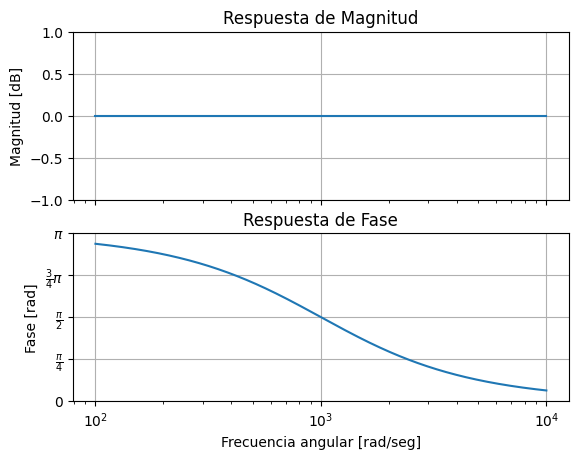

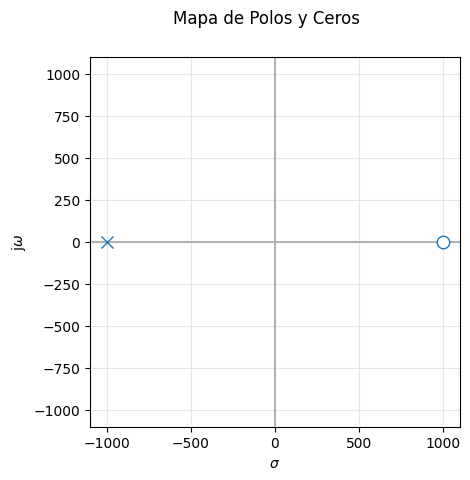

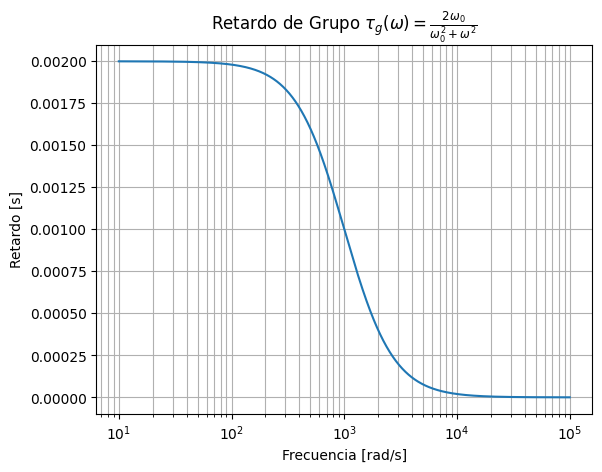

In [21]:
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt

# módulo de SciPy
from scipy import signal as sig

from pytc2.sistemas_lineales import analyze_sys, bodePlot, pzmap, pretty_print_bicuad_omegayq
from pytc2.general import print_latex, a_equal_b_latex_s

# --- Punto 1: Gráficos de la transferencia ---
R3 = 1000  # 1k
C1 = 1e-6  # 1uF
w0 = 1/(R3*C1)

# Numerador y denominador con valores reales
num = [1, -w0]
den = [1, w0]

T = sig.TransferFunction(num, den)

fig_id, axes_hdl = bodePlot(T)
axes_hdl[0].set_ylim([-1, 1]) # Muestra la recta en 0
pzmap(T)

# --- Bloque Agregado: Gráfico del Retardo de Grupo ---
# Rango de frecuencias
w = np.logspace(np.log10(w0/100), np.log10(w0*100), 1000)

# Expresión de tau_g analítica obtenida
tau_g = (2 * w0) / (w0**2 + w**2)

plt.figure()
plt.semilogx(w, tau_g)
plt.title(r'Retardo de Grupo $\tau_g(\omega) = \frac{2\omega_0}{\omega_0^2 + \omega^2}$')
plt.xlabel('Frecuencia [rad/s]')
plt.ylabel('Retardo [s]')
plt.grid(True, which="both", ls="-")

plt.show()

Al observar la respuesta en frecuencia del módulo y la fase es notorio que el comportamiento del filtro es del tipo Pasa todo, o también llamado Rotador de Fase. Este tipo de filtros basan su funcionamiento es dejar inalterada la amplitud de la señal pero alterar la respuesta de fase, haciendo posible demorar la fase, en este caso hasta 180°.

A continuación, se deja el gráfico representado en lápiz y papel que deja explicito los aportes de los polos y ceros en la respuesta en frecuencia y su comportamiento en la fase:

<div align="center">
    <img src="images/2.png" width="600px" style="border: 1px solid #ccc;">
    <br>
</div>




De este modo, podemos normalizar los parámetros de la transferencia anteriormente obtenida definiendo las normas de impedancia $\Omega_Z$ y de frecuencia $\Omega_\omega$:
$$R_3 = R_3' \, \Omega_Z \quad \text{y} \quad C_1 = \frac{C_1'}{\Omega_Z\,\Omega_\omega}$$

Sustituyendo en el producto $R_3\,C_1$
$$R_3\,C_1 = R_3' \cdot \Omega_Z \cdot \frac{C_1'}{\Omega_Z\,\Omega_\omega} = \frac{R_3'\,C_1'}{\Omega_\omega}$$
Y se llega a que la frecuencia de corte $\omega_0$ está escalada según $$\omega_0 = \frac{1}{R_3\,C_1} = \frac{\Omega_\omega}{R_3'\,C_1'} = \Omega_\omega\,\omega_0'$$
donde los valores primados $R_3'$ y $C_1'$ son los valores normalizados de los componentes y $\omega_0'$ es el valor de frecuencia normalizada.

Finalmente, evaluando a la transferencia en la variable compleja normalizada $s = s'\,\Omega_\omega$ $$ T(s) \bigg|_{s\,=\, s'\,\Omega_\omega} = \frac{\Omega_\omega\,s' - \Omega_\omega\,\omega_0'}{\Omega_\omega\,s' + \Omega_\omega\,\omega_0'} = \frac{s' - \omega_0'}{s' + \omega_0'} $$
Propongo como normas $\Omega_\omega = \omega_0 = \frac{1}{R_3\,C_1} \quad$ y $\quad \Omega_Z = R_3$. Entonces 
$$R_3' = \frac{R_3}{\Omega_Z} = \frac{R_3}{R_3} = 1$$
$$C_1' = C_1 \cdot \Omega_Z \cdot \Omega_\omega = C_1 \cdot R_3 \cdot \frac{1}{R_3\,C_1} = 1$$
Por lo tanto $$\omega_0' = 1$$
La transferencia normalizada queda $$T(s') = \frac{s' - 1}{s' + 1}$$

In [ ]:
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt

# módulo de SciPy
from scipy import signal as sig

# módulo de pytc2
from pytc2.sistemas_lineales import analyze_sys, bodePlot, pzmap, pretty_print_bicuad_omegayq
from pytc2.general import print_latex, a_equal_b_latex_s

# --- Punto 4: Gráficos de la transferencia normalizada ---
R3_n = 1  # valor normalizado
C1_n = 1  # valor normalizado
w0_n = 1/(R3_n*C1_n) # valor normalizado

# --- Punto 4: Simulación Numérica Normalizada ---
# Definimos los coeficientes de la transferencia normalizada
num = [1, -1]
den = [1, 1]

T_norm = sig.TransferFunction(num, den)

# 1. Gráfico de Módulo y Fase
fig_id, axes_hdl = bodePlot(T_norm, fig_id=1, filter_description='Pasa-Todo Normalizado')
axes_hdl[0].set_ylim([-1, 1]) 

# 2. Diagrama de Polos y Ceros
pzmap(T_norm, fig_id=2, filter_description='Pasa-Todo Normalizado')

plt.show()

La red que responde a la transferencia normalizada es 
<div align="center">
    <img src="images/pasaTodoNORM.png" width="600px" style="border: 1px solid #ccc;">
    <br>
    <b style="color: gray;">Figura 2: Red normalizada.</b>
</div>
Mediante la directiva Spice <.ac dec 100 0.01 10>, se hizo un barrido en frecuencia desde 0.01 Hz hasta 10 Hz para graficar el comportamiento del filtro
<div align="center">
    <img src="images/rtapasaTodo.png" width="600px" style="border: 1px solid #ccc;">
    <br>
    <b style="color: gray;">Figura 3: Respuesta en frecuencia en módulo y fase de la red normalizada.</b>
</div>
Y es posible observar que la frecuencia de corte normalizada $f_0'$ es exactamente $\frac{1}{2\pi}\,\text{Hz}$ o $0.159\,\text{Hz}$ aproximadamente, lo cual equivale a $\omega_0' = 1 \frac{\text{rad}}{\text{s}}$. Además, también es observable una variación despreciable en el módulo de la transferencia (orden de $\micro$dB), garantizando así una ganancia unitaria en la banda de frecuencia simulada y una rotación de $180$° o $\pi$ radianes en la fase, típico comportamiento de un filtro Pasa Todo o también llamado Rotador de Fase. 

A continuación, se verificarán las transferencias normalizadas y desnormalizadas anteriormente obtenidas mediante el módulo de simulación simbólica SymPy.

In [9]:
import sympy as sp
from pytc2.general import print_latex, a_equal_b_latex_s

s = sp.symbols('s')
V1,V2,Va,Vb = sp.symbols('V1, V2, Va, Vb')
R1,R2,R3,C1 = sp.symbols('R1, R2, R3, C1')

G1 = 1/R1
G2 = 1/R2
G3 = 1/R3
Y_C1 = s*C1

# Ec. de nodos
eq_Va = sp.Eq(Va*(G1 + G2) - V1*G1 - V2*G2,0)
eq_Vb = sp.Eq(Vb*(G3 + Y_C1) - V1*Y_C1,0)
eq_OpAmp = sp.Eq(Va,Vb)

# Resolvemos para V2 = f(V1)
sol = sp.solve([eq_Va, eq_Vb, eq_OpAmp], [V2,Va,Vb])

# Armamos la transferencia T(s) = V2(s) / V1(s)
T = sol[V2] / V1
T = sp.simplify(sp.expand(T))

# Imprimimos el resultado
print("Función Transferencia Simbólica:")
print_latex(a_equal_b_latex_s('T(s)',T))

# La condición de diseño R1 = R2
T_final = T.subs(R2, R1)
print("Transferencia simbólica con R1 = R2:")
print_latex(a_equal_b_latex_s('T(s)', sp.simplify(T_final)))



Función Transferencia Simbólica:


<IPython.core.display.Math object>

Transferencia simbólica con R1 = R2:


<IPython.core.display.Math object>

In [14]:
import sympy as sp
from pytc2.general import print_latex, a_equal_b_latex_s

s_n = sp.symbols('s_n')
V1,V2,Va,Vb = sp.symbols('V1, V2, Va, Vb')
R1,R2,R3,C1 = sp.symbols('R1, R2, R3, C1')

G1 = 1/R1
G2 = 1/R2
G3 = 1/R3
Y_C1 = s_n*C1

eq_Va = sp.Eq(Va*(G1 + G2) - V1*G1 - V2*G2,0)
eq_Vb = sp.Eq(Vb*(G3 + Y_C1) - V1*Y_C1,0)
eq_OpAmp = sp.Eq(Va,Vb)

sol = sp.solve([eq_Va, eq_Vb, eq_OpAmp], [V2,Va,Vb])

T = sol[V2] / V1

# Verificación de la red normalizada (R1=R2=R3=C1=1)
T_norm = T.subs({R1: 1, R2: 1, R3: 1, C1: 1})
T_norm = sp.simplify(sp.expand(T_norm))

print("Función Transferencia de la Red Normalizada:")
print_latex(a_equal_b_latex_s('T(s_n)', T_norm))

Función Transferencia de la Red Normalizada:


<IPython.core.display.Math object>

Se verficó mediante la simulación simbólica que las transferencias obtenidas analíticamente son correctas.

El ejercicio 7 de la guía propone la siguiente red
<div align="center">
    <img src="images/pasaTodo2.png" width="600px" style="border: 1px solid #ccc;">
    <br>
    <b style="color: gray;">Figura 4: Circuito de segundo orden implementado con un OpAmp.</b>
</div>

Aprovechando la herramienta simbólica SymPy, su transferencia está descripta por 

In [20]:
import sympy as sp
from pytc2.general import print_latex, a_equal_b_latex_s

s = sp.symbols('s')
V1,V2,Va,Vb = sp.symbols('V1, V2, Va, Vb')
Ra,Rb,R,C = sp.symbols('Ra, Rb, R, C')

Ga = 1/Ra
Gb = 1/Rb

# R y C en serie
Ys = (s*C) / (s*R*C + 1)

# R y C en paralelo
Yp = (1/R) + s*C

# Ec. de nodos
eq_Va = sp.Eq(Va*(Ga + Gb) - V1*Ga - V2*Gb, 0)
eq_Vb = sp.Eq(Vb*(Ys + Yp) - V1*Ys, 0)

# Condición OpAmp Ideal
eq_OpAmp = sp.Eq(Va, Vb)

# Resolvemos el sistema
sol = sp.solve([eq_Va, eq_Vb, eq_OpAmp], [V2, Va, Vb])

# Armamos la transferencia
T = sol[V2] / V1
T = sp.simplify(T)

print("Función Transferencia Simbólica:")
print_latex(a_equal_b_latex_s('T(s)', T))




Función Transferencia Simbólica:


<IPython.core.display.Math object>

Reacomodando términos y factores, la transferencia de segundo orden queda $$T(s) = \frac{-s²\,\frac{Rb}{Ra} + s \, \frac{R_a - 2\, R_b}{R_a \, R \, C} - \frac{R_b}{R_a\, (R\, C)²}}{s² + s \, \frac{3}{R \, C} + \frac{1}{(R \, C)²}}$$

Reemplazando los valores y relaciones que propone el enunciado, esto es $R = 1 \text{k}\Omega$, $C = 1\,\micro F$ y $\frac{R_a}{R_b} = 5$ 

$$T(s) = \frac{-s²\,0.2 + s\,600 - 200000}{s^2 + s\,3000 + 1000000}$$ $$T(s) = -0.2\,\,(\frac{s² -s\,3\cdot 10³ + 10⁶}{s^2 + s\,3\,10^3 + 10⁶})$$
Con una frecuencia central $\omega_0 = 1000 \frac{\text{rad}}{s}$, cuyos polos y ceros reales son $$p_1 = -381.97, \quad p_2 = -2618.03$$ $$z_1 = 381.97, \quad z_2 = 2618.03$$

Tiene el mismo comportamiento del tipo Pasa Todo que se vió en el caso anterior, con la diferencia fundamental que en este caso tratamos con un filtro de orden superior.

Realizando la simulación correspondiente de esta transferencia en Python se obtiene lo siguiente

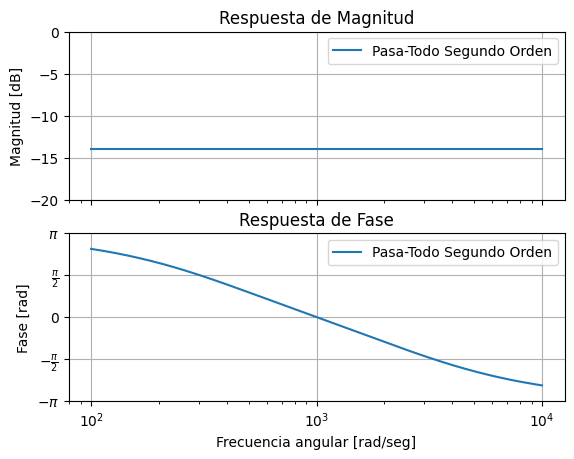

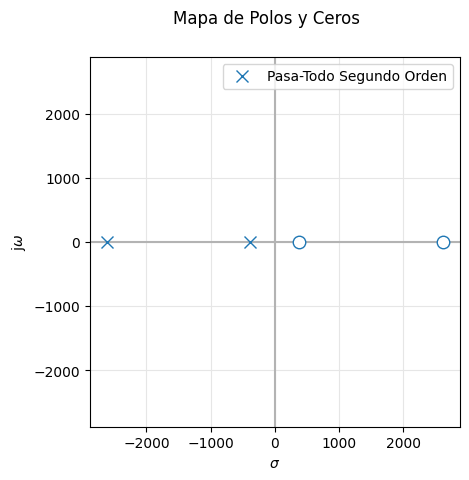

In [11]:
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt

# módulo de SciPy
from scipy import signal as sig

from pytc2.sistemas_lineales import analyze_sys, bodePlot, pzmap, pretty_print_bicuad_omegayq
from pytc2.general import print_latex, a_equal_b_latex_s

# --- Nueva Transferencia de 2do Orden ---
# T(s) = -0.2 * (s^2 - 3000s + 1.000.000) / (s^2 + 3000s + 1.000.000)

k = -0.2
w0_cuad = 1e6
bw = 3e3

# Definimos los coeficientes [s^2, s^1, s^0]
num = k * np.array([1, -bw, w0_cuad])
den = [1, bw, w0_cuad]

T = sig.TransferFunction(num, den)

# 1. Gráfico de Módulo y Fase
fig_id, axes_hdl = bodePlot(T, fig_id=1, filter_description='Pasa-Todo Segundo Orden')
axes_hdl[0].set_ylim([-20, 0]) 

# 2. Diagrama de Polos y Ceros
pzmap(T, fig_id=2, filter_description='Pasa-Todo Segundo Orden')

plt.show()

Las principales diferencias entre la Red de primer y segundo orden radican principalmente en el factor de ganancia y en la rotación de fase.
- El filtro de primer orden, presenta una respuesta en frecuencia con una ganancia unitaria (0 dB) con la condición que en el lazo de realimentación negativa se cumpla que $R_1 = R_2$, mientras que su respuesta de fase presenta una rotación desde 180° hasta 0°.
- El filtro de segundo orden, en cambio, presenta una atenuación aproximadamente de 14 dB para toda frecuencia cuando se cumple que $R_a = 5\,R_b$, mientras que su respuesta de fase presenta una rotación desde 180° hasta -180°, es decir una rotación completa de 360°.
  
Además está garantizada la estabilidad de ambos filtros, puesto que los polos se encuentran en el semiplano complejo izquierdo. 